## Parcial: Carga de dataset y Librerias 



In [94]:
# 1. Carga de Librerías y Dataset del P1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carga del Dataset del TP2
csv_path = 'reglamento_nuevo_unificado.csv'
df_raw = pd.read_csv(csv_path)
print(f"Dataset del TP2 cargado exitosamente: {df_raw.shape[0]:,} filas.")
#Carga del Dataset Clean creado en la parte 1
df_clean= pd.read_csv('reglamento_dfclean.csv')
print(f"Dataset df_clean cargado exitosamente: {df_clean.shape[0]:,} filas.")

Dataset del TP2 cargado exitosamente: 64,295 filas.
Dataset df_clean cargado exitosamente: 64,295 filas.


## Preguntas para el parcial: Remonta no remonta
1. Elegir una materia y analizar entre carreras la cantidad de alumnos que pasan la materia despues de haber tenido un mal primer parcial
2. Analizar de estos alumnos que tal les fue en el semestre anterior 
3. Ver cuantas materias estan llevando estos alumnos y que relacion tiene esto con su rendimiento en la materia elegida


In [95]:
# =============================================================================
# 2. FILTRAR 
# =============================================================================
print("\n🔍 Filtrando PROBABILIDAD...")
mask = df_clean['Asignatura'].str.upper().str.contains('PROBABILIDAD', na=False)
df_clean_probabilidad = df_clean[mask].copy()
print(f"✅ Registros de PROBABILIDAD: {len(df_clean_probabilidad):,}")
print(f"   Estudiantes únicos: {df_clean_probabilidad['ALUMNO_ID'].nunique():,}")
df_anho_semestre = df_clean_probabilidad.groupby(['Anho', 'Semestre']).agg({'ALUMNO_ID': 'nunique'}).reset_index()
df_anho_semestre.head(10)


🔍 Filtrando PROBABILIDAD...
✅ Registros de PROBABILIDAD: 1,467
   Estudiantes únicos: 1,084


,Anho,Semestre,ALUMNO_ID
0,2024,2,847
1,2025,2,620


## Parcial: Remonta no remonta

In [96]:
# Filtrar aquellos alumnos con un "mal primer parcial" (< 50)
mal_primer_parcial = df_clean_probabilidad[df_clean_probabilidad['Primer_Par_Clean'] < 50].copy()

# -------------------------------------------------------------
# NUEVO: Quedarse únicamente con un registro único por cada alumno
# -------------------------------------------------------------
mal_primer_parcial = mal_primer_parcial.drop_duplicates(subset=['ALUMNO_ID'], keep='first')

# 4. Agrupar por carrera para analizar la cantidad total con mal parcial, cuántos pasaron y su tasa de éxito
analisis_carreras = mal_primer_parcial.groupby('Carrera_Nombre').agg(
    Total_Mal_Parcial=('ALUMNO_ID', 'count'),  # Al no haber duplicados, 'count' o 'nunique' darán exactamente lo mismo
    Pasan_Materia=('Target', lambda x: (x == 1).sum()),
    Tasa_Exito_Porcentaje=('Target', lambda x: (x == 1).mean() * 100)
).reset_index()

# Ordenar de mayor a menor según los alumnos que lograron remontar
analisis_carreras = analisis_carreras.sort_values(by='Pasan_Materia', ascending=False)

print("--- Análisis de Alumnos que Remontan con Mal Primer Parcial en Probabilidad (Estudiantes Únicos) ---")
print(analisis_carreras.to_string(index=False))
print("--- Cantidad total de alumnos      ", analisis_carreras.Total_Mal_Parcial.sum(), "          ", analisis_carreras.Pasan_Materia.sum())

porcentaje = (analisis_carreras.Pasan_Materia.sum() / analisis_carreras.Total_Mal_Parcial.sum()) * 100
print(f"Porcentaje de Alumnos que pasaron rindiendo mal el primer parcial= {porcentaje:.2f}%")

--- Análisis de Alumnos que Remontan con Mal Primer Parcial en Probabilidad (Estudiantes Únicos) ---
      Carrera_Nombre  Total_Mal_Parcial  Pasan_Materia  Tasa_Exito_Porcentaje
          Ing. Civil                301             56              18.604651
Ing. Electromecánica                161             30              18.633540
    Ing. Mecatrónica                 58             10              17.241379
     Ing. Industrial                 32              8              25.000000
     Ing. Geográfica                 74              4               5.405405
    Ing. Electrónica                 20              2              10.000000
       Ing. Mecánica                 26              2               7.692308
--- Cantidad total de alumnos       672            112
Porcentaje de Alumnos que pasaron rindiendo mal el primer parcial= 16.67%


## Parcial: Remonta no remonta
1. Elegir una materia y analizar entre carreras la cantidad de alumnos que pasan la materia despues de haber tenido un mal primer parcial



In [97]:
# 1. Obtenemos la lista de IDs únicos de los alumnos que tuvieron mal primer parcial en Probabilidad
ids_mal_parcial = mal_primer_parcial['ALUMNO_ID'].unique()

# 2. Definimos las dos materias que quieres analizar (puedes cambiar los nombres después)
materia1 = 'OPTICA Y ONDAS'
materia2 = 'ECUACIONES DIFERENCIALES'

# 3. Filtramos el DataFrame general para quedarnos solo con los alumnos del grupo anterior que cursan la materia 1
alumnos_materia1 = df_clean[
    (df_clean['ALUMNO_ID'].isin(ids_mal_parcial)) & 
    (df_clean['Asignatura'].str.upper().str.contains(materia1, na=False))
]['ALUMNO_ID'].unique()

# 4. Hacemos lo mismo para la materia 2
alumnos_materia2 = df_clean[
    (df_clean['ALUMNO_ID'].isin(ids_mal_parcial)) & 
    (df_clean['Asignatura'].str.upper().str.contains(materia2, na=False))
]['ALUMNO_ID'].unique()

# 5. Encontramos la intersección: alumnos que aparecen en ambas listas
ids_ambas_materias = set(alumnos_materia1).intersection(set(alumnos_materia2))

# 6. Creamos el DataFrame final con los datos de esos alumnos
df_ambas_materias = df_clean[df_clean['ALUMNO_ID'].isin(ids_ambas_materias)].copy()

# Resultado
print(f"--- Alumnos con mal primer parcial en Probabilidad que cursan '{materia1}' y '{materia2}' ---")
print(f"Cantidad de estudiantes únicos: {len(ids_ambas_materias)}")
df_anho_semestre3materias = df_ambas_materias.groupby(['Anho', 'Semestre']).agg({'ALUMNO_ID': 'nunique'}).reset_index()
df_anho_semestre3materias.head(10)

--- Alumnos con mal primer parcial en Probabilidad que cursan 'OPTICA Y ONDAS' y 'ECUACIONES DIFERENCIALES' ---
Cantidad de estudiantes únicos: 148


,Anho,Semestre,ALUMNO_ID
0,2024,2,142
1,2025,1,148
2,2025,2,140


## Codigo prueba de Regresion

In [98]:
# =============================================================================
# REGRESIÓN LOGÍSTICA: Remontar Probabilidad con Óptica y Ondas / Ecuaciones Diferenciales
# =============================================================================

# 1. Partimos de nuestro dataset de alumnos con mal primer parcial en Probabilidad (ya limpios y únicos)
df_modelo = mal_primer_parcial.copy()

# 2. Creamos indicadores (variables dummy 0 o 1) para ver si cursaron Óptica y Ondas y Ecuaciones Diferenciales
materia1 = 'OPTICA Y ONDAS'
materia2 = 'ECUACIONES DIFERENCIALES'

# Obtenemos los conjuntos de IDs que cursan cada materia
alumnos_materia1 = set(df_clean[df_clean['Asignatura'].str.upper().str.contains(materia1, na=False)]['ALUMNO_ID'])
alumnos_materia2 = set(df_clean[df_clean['Asignatura'].str.upper().str.contains(materia2, na=False)]['ALUMNO_ID'])

# Añadimos las columnas al DataFrame del modelo (1 si cursan la materia, 0 si no)
df_modelo['Cursa_Optica'] = df_modelo['ALUMNO_ID'].isin(alumnos_materia1).astype(int)
df_modelo['Cursa_Ecuaciones'] = df_modelo['ALUMNO_ID'].isin(alumnos_materia2).astype(int)

# 3. Definimos las Features (X) y el Target (y)
# Target: 'Target' (1 si pasó la materia, 0 si no)
# Features: Nota del primer parcial + si cursan las otras dos materias
features = ['Primer_Par_Clean', 'Cursa_Optica', 'Cursa_Ecuaciones']
X = df_modelo[features].copy()
y = df_modelo['Target'].copy()

# Rellenar posibles valores nulos en las notas si los hubiera
X.fillna(0, inplace=True)

# 4. Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Entrenar la Regresión Logística
modelo_log_reg = LogisticRegression(random_state=42)
modelo_log_reg.fit(X_train, y_train)

# 6. Evaluar el modelo
y_pred = modelo_log_reg.predict(X_test)
y_prob = modelo_log_reg.predict_proba(X_test)[:, 1]

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

if len(np.unique(y_test)) > 1:
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 7. Ver el peso (coeficientes) de cada variable en la decisión de remontar
coeficientes = pd.DataFrame({
    'Variable': features,
    'Coeficiente (Peso)': modelo_log_reg.coef_[0]
})
print("\n--- PESO DE LAS VARIABLES EN LA REGRESIÓN ---")
print(coeficientes.to_string(index=False))

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       113
           1       0.83      0.23      0.36        22

    accuracy                           0.87       135
   macro avg       0.85      0.61      0.64       135
weighted avg       0.86      0.87      0.83       135

ROC-AUC Score: 0.7995

--- PESO DE LAS VARIABLES EN LA REGRESIÓN ---
        Variable  Coeficiente (Peso)
Primer_Par_Clean            0.046973
    Cursa_Optica           -0.969049
Cursa_Ecuaciones            1.094493


## Matriz De Confucion

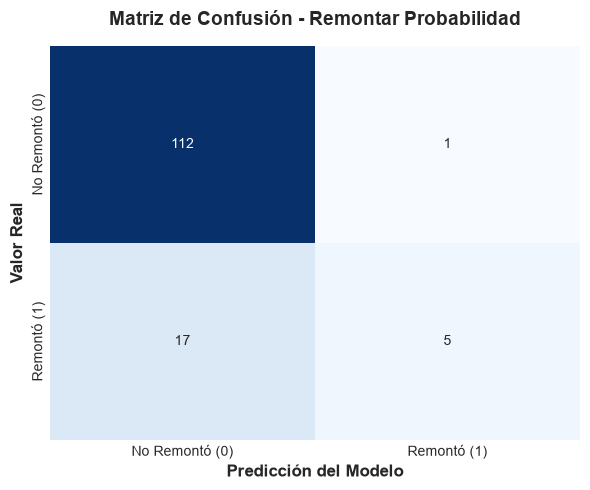

In [99]:
# =============================================================================
# VISUALIZACIÓN: Matriz de Confusión
# =============================================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 2. Configurar la visualización
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Remontó (0)', 'Remontó (1)'],
            yticklabels=['No Remontó (0)', 'Remontó (1)'])

plt.xlabel('Predicción del Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.title('Matriz de Confusión - Remontar Probabilidad', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

## Graficos

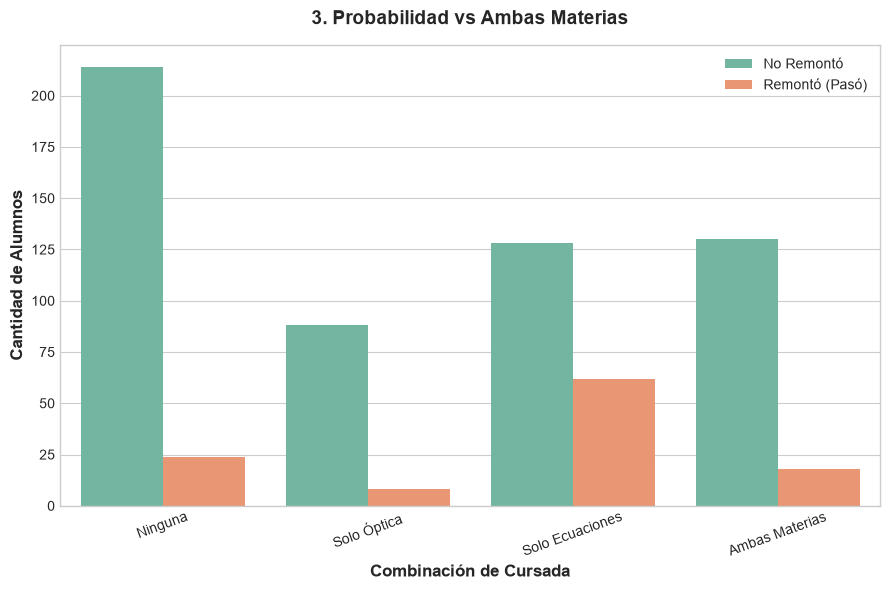

In [104]:
# =============================================================================
# VISUALIZACIÓN: Probabilidad vs Ambas Materias (Gráfico Individual)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Preparar los datos
df_grafico_unico = mal_primer_parcial.copy()

materia1 = 'OPTICA Y ONDAS'
materia2 = 'ECUACIONES DIFERENCIALES'

alumnos_materia1 = set(df_clean[df_clean['Asignatura'].str.upper().str.contains(materia1, na=False)]['ALUMNO_ID'])
alumnos_materia2 = set(df_clean[df_clean['Asignatura'].str.upper().str.contains(materia2, na=False)]['ALUMNO_ID'])

df_grafico_unico['Cursa_Optica'] = df_grafico_unico['ALUMNO_ID'].isin(alumnos_materia1).astype(int)
df_grafico_unico['Cursa_Ecuaciones'] = df_grafico_unico['ALUMNO_ID'].isin(alumnos_materia2).astype(int)

def definir_combinacion(row):
    if row['Cursa_Optica'] == 1 and row['Cursa_Ecuaciones'] == 1:
        return 'Ambas Materias'
    elif row['Cursa_Optica'] == 1:
        return 'Solo Óptica'
    elif row['Cursa_Ecuaciones'] == 1:
        return 'Solo Ecuaciones'
    else:
        return 'Ninguna'

df_grafico_unico['Grupo_Materias'] = df_grafico_unico.apply(definir_combinacion, axis=1)
df_grafico_unico['Estado_Remontada'] = df_grafico_unico['Target'].map({1: 'Remontó (Pasó)', 0: 'No Remontó'})

# 2. Configurar y graficar solo este cuadro
plt.figure(figsize=(9, 6))
orden_grupos = ['Ninguna', 'Solo Óptica', 'Solo Ecuaciones', 'Ambas Materias']

sns.countplot(
    data=df_grafico_unico, 
    x='Grupo_Materias', 
    hue='Estado_Remontada', 
    palette='Set2', 
    order=orden_grupos
)

plt.title('3. Probabilidad vs Ambas Materias', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Combinación de Cursada', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Alumnos', fontsize=12, fontweight='bold')
plt.xticks(rotation=20)
plt.legend(title='')

plt.tight_layout()
plt.show()